In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("data/employee_attrition.csv")

In [3]:
print(f"Shape: {df.shape}")
print(f"\n{df.dtypes}")
print(f"\n{df.info()}")
print(f"\n{round(df.describe(), 2)}")

Shape: (2500, 19)

age                            int64
gender                        object
education                     object
department                    object
job_level                     object
years_at_company             float64
years_in_role                float64
num_companies_worked           int64
monthly_income               float64
overtime                      object
work_life_balance            float64
job_satisfaction               int64
relationship_satisfaction      int64
environment_satisfaction     float64
training_last_year           float64
performance_rating             int64
distance_from_home             int64
business_travel               object
attrition                      int64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        2500 non-null

In [4]:
quantity = df['attrition'].value_counts()
percent  = df['attrition'].value_counts(normalize=True) * 100
print(f"O lai     {quantity[0]:>5} - ty le {percent[0]:.1f}%")
print(f"Nghi lam  {quantity[1]:>5} - ty le {percent[1]:.1f}%")

print("""
        Nhận xét: Dataset bị imbalanced  (~70/30).
        Phải dùng Recall, F1, ROC-AUC thay vì Accuracy làm metric chính.
""")




O lai      1747 - ty le 69.9%
Nghi lam    753 - ty le 30.1%

        Nhận xét: Dataset bị imbalanced  (~70/30).
        Phải dùng Recall, F1, ROC-AUC thay vì Accuracy làm metric chính.



In [5]:
print("--- Missing Values ---")
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
report = pd.DataFrame({'Count': missing, 'Percent(%)': missing_pct})
print(report[report['Count'] > 0])
print("--- Outliers ---")
numeric_col = df.select_dtypes(['float64', "int64"]).columns
for col in numeric_col:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = (df[col] < lower) | (df[col] > upper)
    
    if outliers.sum() > 0:
        print(f"{col:20}: {outliers.sum()} - range [{lower:.1f}, {upper:.1f}]")

--- Missing Values ---
                          Count  Percent(%)
monthly_income              111        4.44
work_life_balance           124        4.96
environment_satisfaction    112        4.48
training_last_year           72        2.88
--- Outliers ---
age                 : 10 - range [2.5, 78.5]
years_at_company    : 132 - range [-5.8, 12.6]
years_in_role       : 169 - range [-3.5, 7.7]
monthly_income      : 50 - range [2400.0, 12000.0]
performance_rating  : 67 - range [1.5, 5.5]


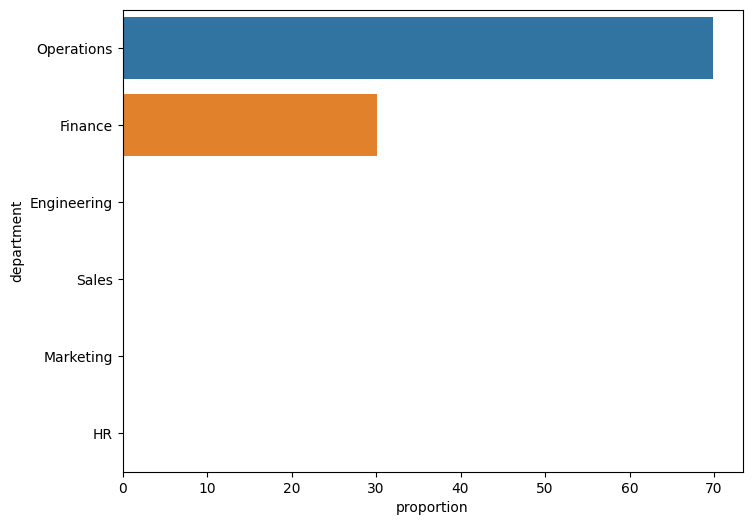

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.barplot(
    data = df,
    x = percent,
    y = 'department',
    hue = 'department'
)

plt.show()

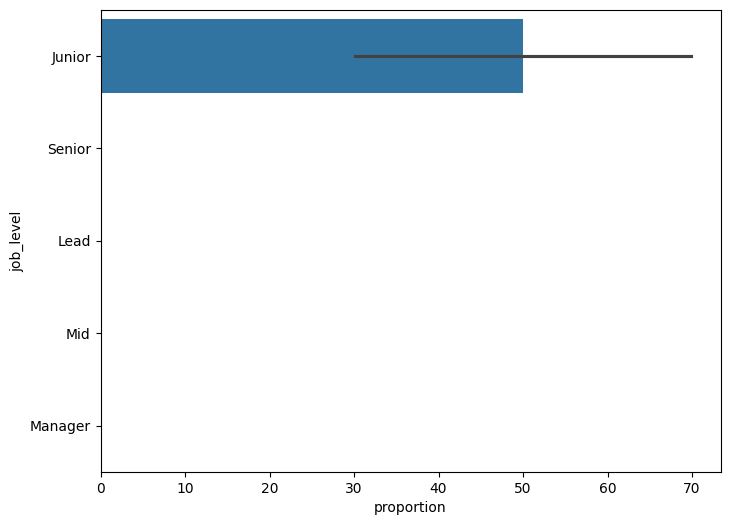

In [7]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=df,
    x = percent,
    y = 'job_level'
)

plt.show()

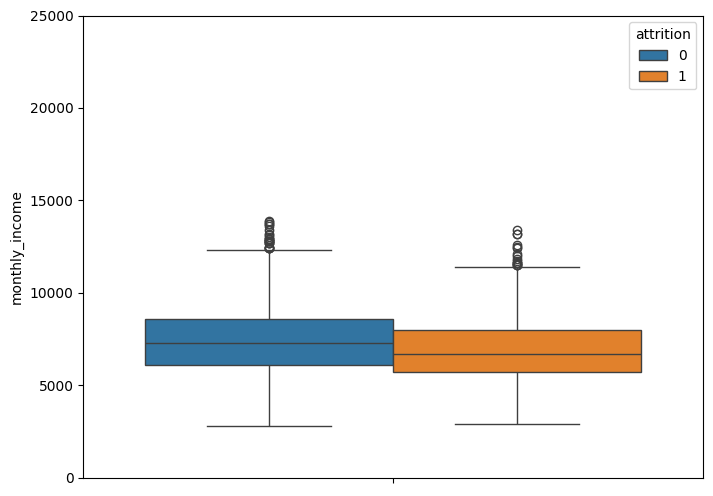

In [8]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, y='monthly_income', hue='attrition')
plt.ylim(0, 25000) 
plt.show()

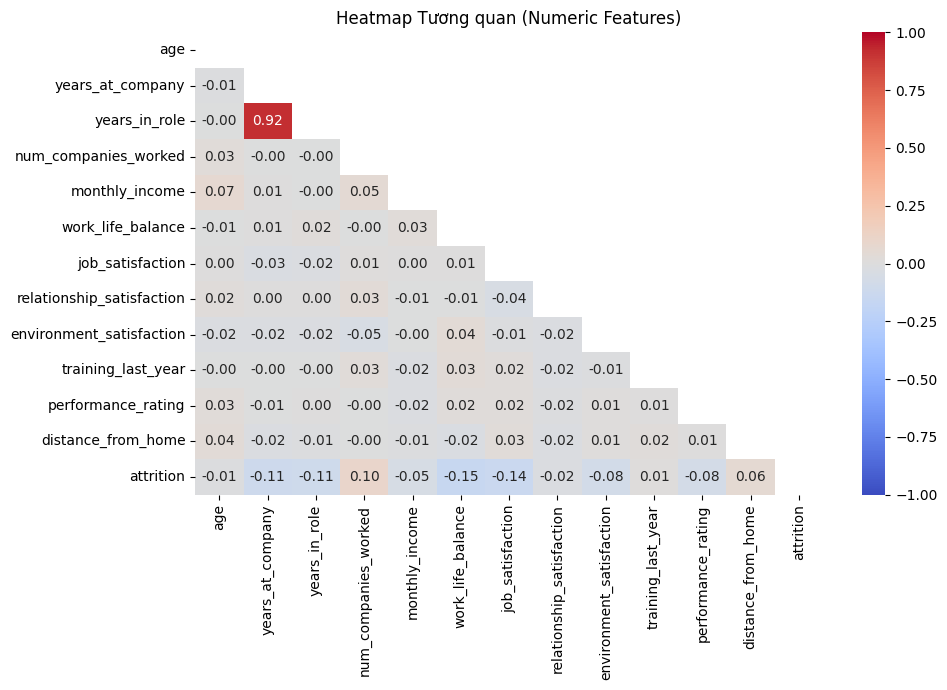

In [9]:
plt.figure(figsize=(10, 7))
corr = df.select_dtypes(include=['float64', 'int64']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool)) 
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, center=0)
plt.title("Heatmap Tương quan (Numeric Features)")
plt.tight_layout()
plt.savefig("output/eda_heatmap.png", dpi=150)
plt.show()

In [10]:
before = len(df)
df = df[(df['age'].isna()) | (df['age'] < 100)]
df = df[(df['monthly_income'].isna()) | (df['monthly_income'] < 50000)]
df = df.reset_index(drop=True)
print(f"Dropped {before - len(df)} outlier rows → còn {len(df)} rows")

Dropped 20 outlier rows → còn 2480 rows


In [11]:
df['monthly_income'] = df['monthly_income'].fillna(
    df.groupby('job_level')['monthly_income'].transform('median')
)

df['work_life_balance'] = df['work_life_balance'].fillna(df['work_life_balance'].median())
df['environment_satisfaction'] = df['environment_satisfaction'].fillna(df['environment_satisfaction'].median())
df['training_last_year'] = df['training_last_year'].fillna(0)

df['role_tenure_ratio'] = df['years_in_role'] / (df['years_at_company'] + 1)

level_median = df.groupby('job_level')['monthly_income'].transform('median')
df['income_vs_level'] = df['monthly_income'] / level_median

df['total_satisfaction'] = (
    df['job_satisfaction'] +
    df['relationship_satisfaction'] +
    df['environment_satisfaction'] +
    df['work_life_balance']
)

In [12]:
encode_col =  ['gender', 'education', 'department', 'job_level', 'overtime', 'business_travel']
df_final = pd.get_dummies(df, columns=encode_col, drop_first=True, dtype=int)


print(f"Shape sau encoding: {df_final.shape}")
print(f"Null còn lại: {df_final.isnull().sum().sum()}")

Shape sau encoding: (2480, 32)
Null còn lại: 0


In [13]:
from sklearn.model_selection import train_test_split

X = df_final.drop(columns=['attrition'])
y = df_final['attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")



Train: 1860 | Test: 620


In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

print(f"{'Depth':<8}{'Train Acc':>10}{'Test Acc':>10}{'F1':>8}{'Overfit':>10}")
print("-" * 44)

dt_results = {}
for depth in [3, 5, 7, 10, None]:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    train_pred = dt.predict(X_train)
    test_pred = dt.predict(X_test)
    test_proba = dt.predict_proba(X_test)[:,1]
    
    result = {
        'train_acc': accuracy_score(y_train, train_pred),
        'test_acc':  accuracy_score(y_test, test_pred),
        'f1':        f1_score(y_test, test_pred),
        'gap': accuracy_score(y_train, train_pred) - accuracy_score(y_test, test_pred),
        'model':     dt
    }
    
    dt_results[depth] = result
    label = str(depth) if depth else 'None'
    print(f"{label:<8}{result['train_acc']:>10.4f}{result['test_acc']:>10.4f}"
          f"{result['f1']:>8.4f}{result['gap']:>10.4f}")
    

best_depth = max(dt_results, key=lambda d: dt_results[d]['f1'])
best_dt = dt_results[best_depth]['model']
print(f"\nBest DT: max_depth ={best_depth}")
    


Depth    Train Acc  Test Acc      F1   Overfit
--------------------------------------------
3           0.7333    0.7000  0.3162    0.0333
5           0.7694    0.7032  0.3429    0.0661
7           0.8108    0.7016  0.3771    0.1091
10          0.9059    0.6468  0.3761    0.2591
None        1.0000    0.6016  0.3683    0.3984

Best DT: max_depth =7


In [16]:

print(f"{'n_trees':<8}{'Train Acc':>10}{'Test Acc':>10}{'F1':>8}{'AUC':>10}")
print("-" * 44)

rf_results = {}
for n in [10, 50, 100, 200, 500]:
    rf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    train_pred = rf.predict(X_train)
    test_pred = rf.predict(X_test)
    test_proba = rf.predict_proba(X_test)[:,1]
    
    result = {
        'train_acc': accuracy_score(y_train, train_pred),
        'test_acc':  accuracy_score(y_test, test_pred),
        'f1':        f1_score(y_test, test_pred),
        'auc':       roc_auc_score(y_test, test_proba),
        'model':     rf
    }
    
    rf_results[n] = result
    print(f"{n:<10}{result['train_acc']:>10.4f}{result['test_acc']:>10.4f}"
          f"{result['f1']:>8.4f}{result['auc']:>8.4f}")
    
best_n_trees = max(rf_results, key=lambda d: rf_results[d]['f1'])
best_rf = rf_results[best_n_trees]['model']
print(f"\nBest RF: n_trees  ={best_n_trees}")
    

n_trees  Train Acc  Test Acc      F1       AUC
--------------------------------------------
10            0.9812    0.6968  0.3333  0.6389
50            0.9995    0.7161  0.3714  0.6983
100           1.0000    0.7210  0.3887  0.6976
200           1.0000    0.7242  0.3736  0.7116
500           1.0000    0.7339  0.3911  0.7158

Best RF: n_trees  =500


In [26]:
def metrics_row(name, model, X, y):
    pred = model.predict(X)
    prob = model.predict_proba(X)[:, 1]
    return {
        'Model': name,
        'Accuracy':  accuracy_score(y, pred),
        'Precision': precision_score(y, pred),
        'Recall':    recall_score(y, pred),
        'F1':        f1_score(y, pred),
        'ROC-AUC':   roc_auc_score(y, prob),
    }

rows = [
    metrics_row(f"Decision Tree (depth={best_depth})", best_dt, X_test, y_test),
    metrics_row("Random Forest (100 trees)", best_rf, X_test, y_test),
]
results_df = pd.DataFrame(rows).set_index('Model')
print(results_df.round(4))



                           Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                                  
Decision Tree (depth=7)      0.7016     0.5091  0.2995  0.3771   0.6666
Random Forest (100 trees)    0.7339     0.6310  0.2834  0.3911   0.7158


PHẦN 1: EDA
Shape: (2500, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        2500 non-null   int64  
 1   gender                     2500 non-null   object 
 2   education                  2500 non-null   object 
 3   department                 2500 non-null   object 
 4   job_level                  2500 non-null   object 
 5   years_at_company           2500 non-null   float64
 6   years_in_role              2500 non-null   float64
 7   num_companies_worked       2500 non-null   int64  
 8   monthly_income             2389 non-null   float64
 9   overtime                   2500 non-null   object 
 10  work_life_balance          2376 non-null   float64
 11  job_satisfaction           2500 non-null   int64  
 12  relationship_satisfaction  2500 non-null   int64  
 13  environment_satisf

C:\Users\lequa\AppData\Local\Temp\ipykernel_17148\169195153.py:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['monthly_income'] < 30000],  # filter outliers để nhìn rõ
C:\Users\lequa\AppData\Local\Temp\ipykernel_17148\169195153.py:97: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,0].set_xticklabels(['Ở lại (0)', 'Nghỉ việc (1)'])


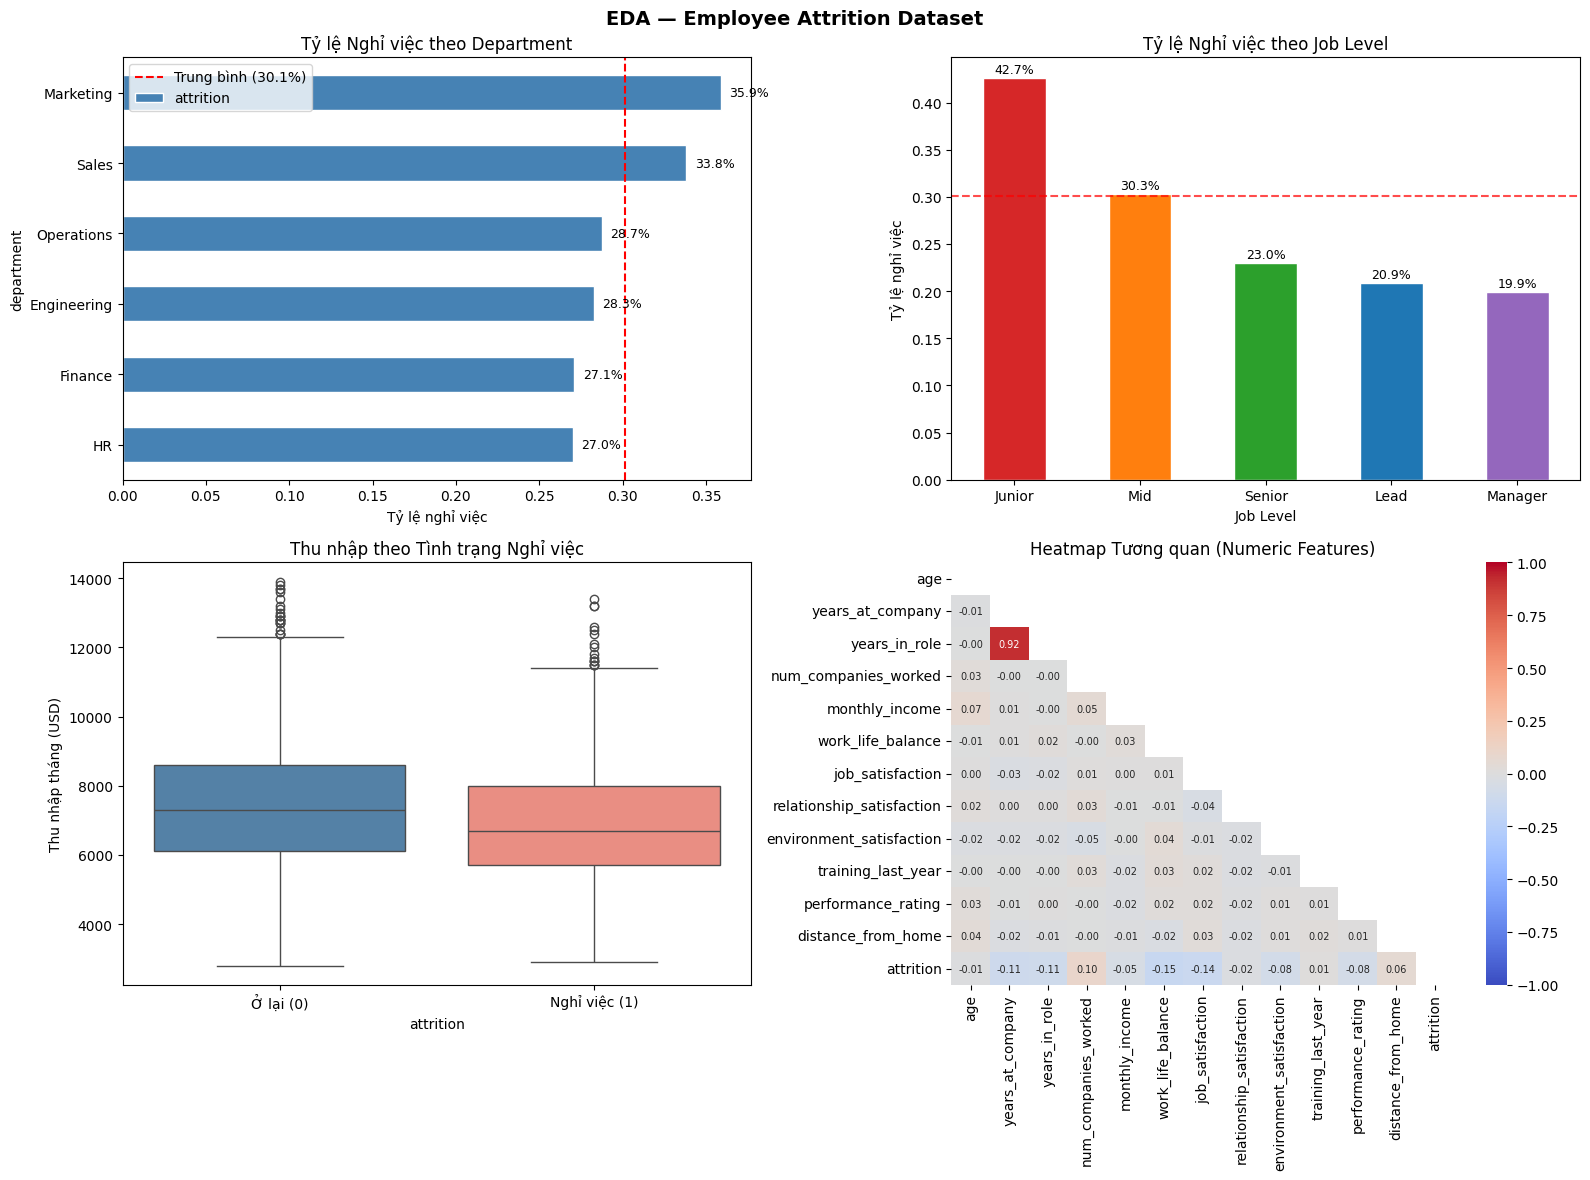

✅ Saved: output/eda_charts.png

📌 Nhận xét EDA:
  • Department có tỷ lệ nghỉ cao nhất: Marketing (35.9%)
  • Department có tỷ lệ nghỉ thấp nhất: HR (27.0%)
  • Job level Junior nghỉ nhiều nhất — phù hợp thực tế (ít gắn bó, nhiều cơ hội khác)
  • Người nghỉ việc có thu nhập thấp hơn người ở lại → lương là yếu tố quan trọng


PHẦN 2: PREPROCESSING
Dropped 20 rows → còn 2480 rows
Missing sau fill: 0
Shape sau encoding: (2480, 32)
Null còn lại: 0

PHẦN 3: TRAIN & EVALUATE
Train: 1984 | Test: 496

--- Decision Tree ---
Depth    Train Acc  Test Acc      F1 Overfit Gap
----------------------------------------------------
3           0.7329    0.6935  0.3153      0.0393
5           0.7651    0.6895  0.2451      0.0756
7           0.8191    0.6492  0.3459      0.1699 ← overfit!
10          0.9148    0.6290  0.3134      0.2858 ← overfit!
None        1.0000    0.6109  0.3588      0.3891 ← overfit!

Best DT: max_depth = None

--- Random Forest ---
N trees    Train Acc  Test Acc      F1     AUC
---

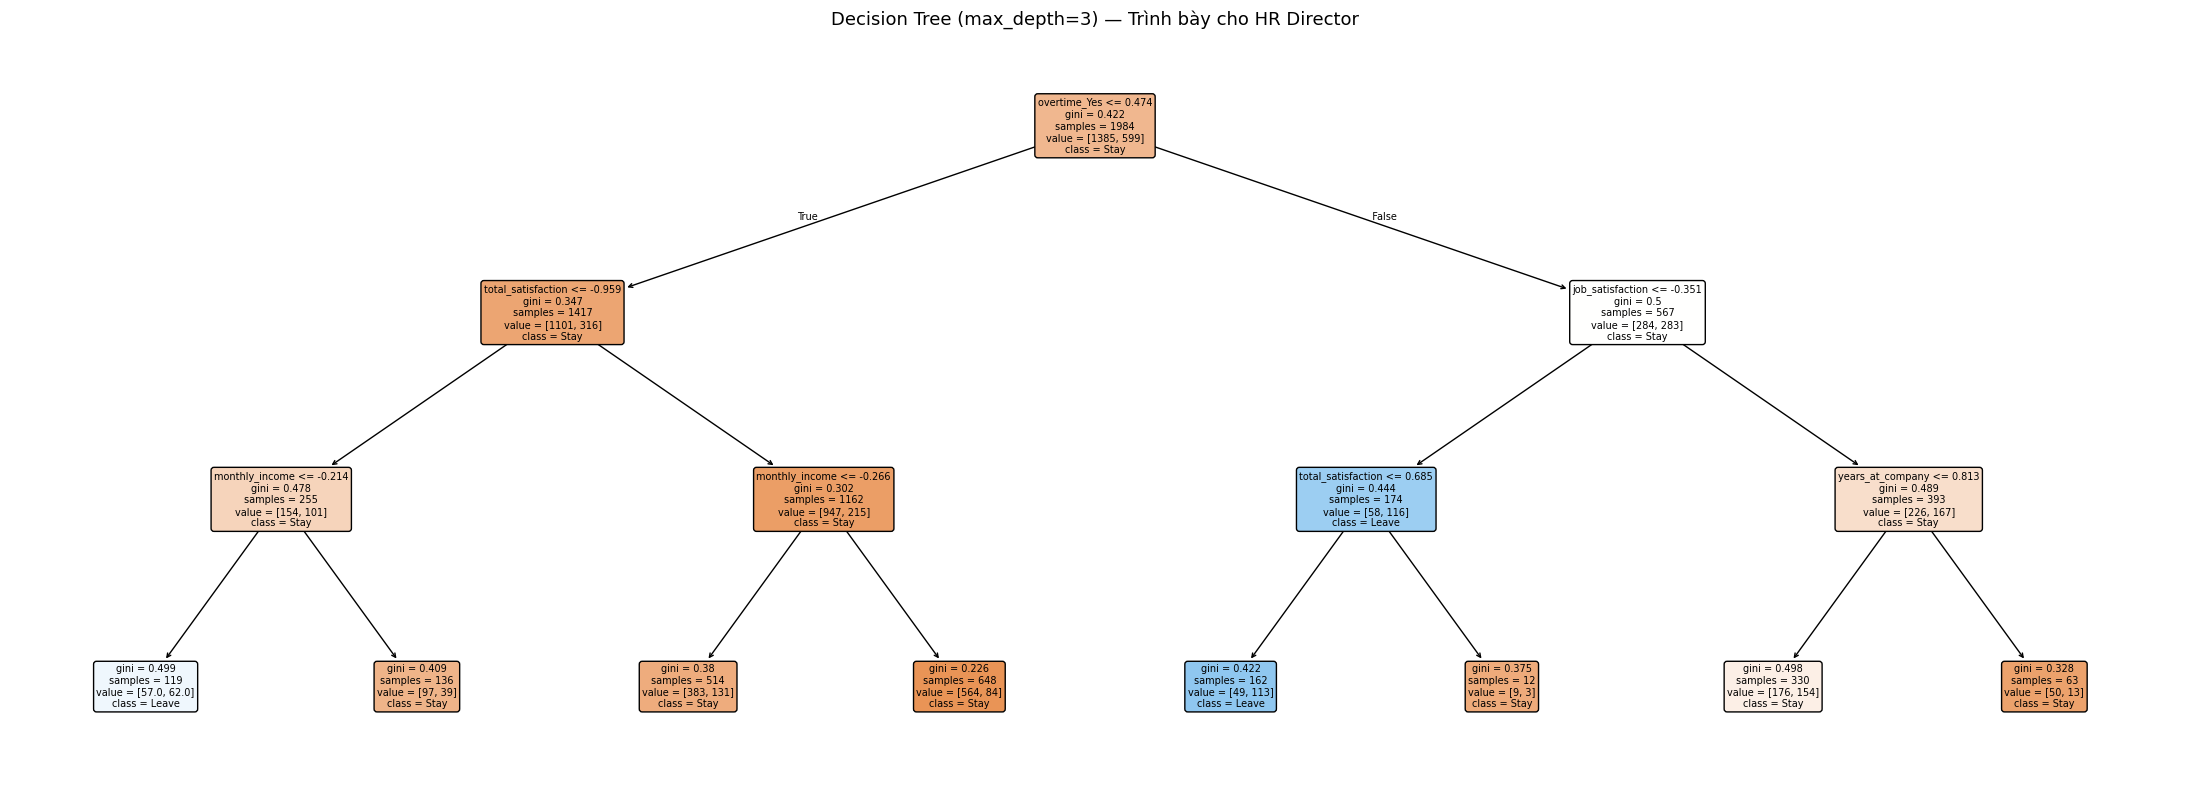

✅ Saved: output/tree_visualization.png


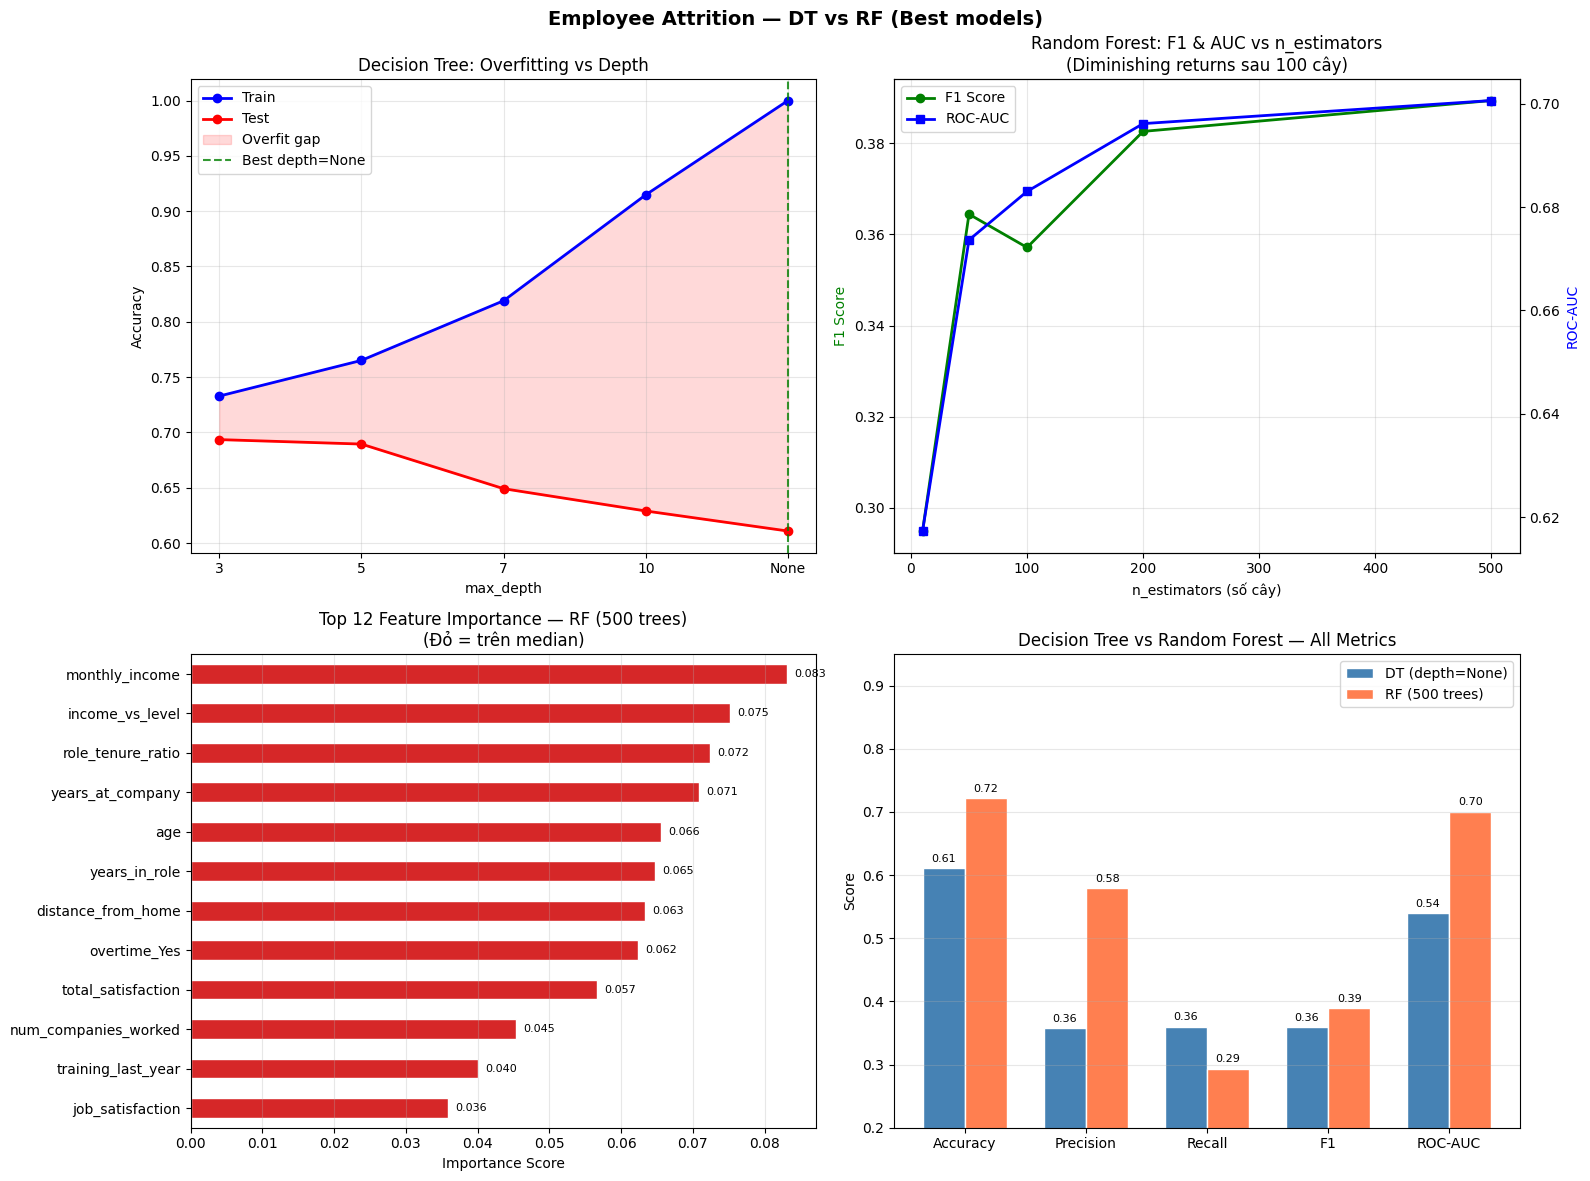

✅ Saved: output/model_charts.png

📊 So sánh Top 3 Feature Importance:
  Decision Tree: ['monthly_income', 'age', 'years_at_company']
  Random Forest: ['monthly_income', 'income_vs_level', 'role_tenure_ratio']

  Overlap: {'monthly_income'}
  → DT và RF không đồng ý nhiều — RF ổn định hơn, tin RF hơn

  Insights cho HR Director:
  • total_satisfaction và job_satisfaction cao → nhân viên ít nghỉ
  • overtime = Yes → nguy cơ nghỉ cao (burnout)
  • income_vs_level thấp → cảm thấy bị trả thấp hơn xứng đáng → nghỉ
  → Gợi ý: Tăng lương cho Junior, giảm overtime, cải thiện môi trường làm việc



In [28]:
# ============================================================
# LỜI GIẢI CHUẨN — Dự đoán Nghỉ việc Nhân viên
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

# ============================================================
# PHẦN 1 — EDA
# ============================================================
print("=" * 60)
print("PHẦN 1: EDA")
print("=" * 60)

df = pd.read_csv("data/employee_attrition.csv")
print(f"Shape: {df.shape}")
print(f"\n{df.info()}")
print(f"\n{df.describe().round(2)}")

# 1.2 Class balance
print("\n--- Class Balance ---")
counts = df['attrition'].value_counts()
pcts   = df['attrition'].value_counts(normalize=True) * 100
print(f"  Ở lại   (0): {counts[0]:>5}  ({pcts[0]:.1f}%)")
print(f"  Nghỉ    (1): {counts[1]:>5}  ({pcts[1]:.1f}%)")
print("""
  Nhận xét: Imbalanced ~70:30 — ít nghiêm trọng hơn Day 2 (87:13)
  → Accuracy vẫn bị ảnh hưởng nhưng không quá tệ như Day 2
  → Vẫn ưu tiên F1 và Recall làm metric chính
  → class_weight='balanced' có thể giúp cải thiện Recall
""")

# 1.3 Missing values + Outliers
print("--- Missing Values ---")
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
report = pd.DataFrame({'Count': missing, 'Percent(%)': missing_pct})
print(report[report['Count'] > 0])

print("\n--- Outlier Detection ---")
numeric_cols = df.select_dtypes(['float64', 'int64']).columns
for col in numeric_cols:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    if n_out > 0:
        print(f"  {col:30}: {n_out:>4} outliers | [{lower:.1f}, {upper:.1f}]")
print(f"\n  ⚠️  age max={df['age'].max()} → age > 100 không thực tế, sẽ drop")
print(f"  ⚠️  monthly_income max={df['monthly_income'].max():.0f} → > 50000 bất thường, sẽ drop")

# 1.4 Vẽ 4 EDA charts
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1: Attrition rate theo department — ĐÚNG cách tính rate
dept_rate = (df.groupby('department')['attrition']
               .mean()
               .sort_values(ascending=True))
dept_rate.plot(kind='barh', ax=axes[0,0], color='steelblue', edgecolor='white')
axes[0,0].set_title("Tỷ lệ Nghỉ việc theo Department")
axes[0,0].set_xlabel("Tỷ lệ nghỉ việc")
axes[0,0].axvline(x=df['attrition'].mean(), color='red',
                   linestyle='--', label=f"Trung bình ({df['attrition'].mean():.1%})")
axes[0,0].legend()
for i, v in enumerate(dept_rate):
    axes[0,0].text(v + 0.005, i, f'{v:.1%}', va='center', fontsize=9)

# Chart 2: Attrition rate theo job_level
level_order = ['Junior', 'Mid', 'Senior', 'Lead', 'Manager']
level_rate = df.groupby('job_level')['attrition'].mean().reindex(level_order)
level_rate.plot(kind='bar', ax=axes[0,1],
                color=['#d62728','#ff7f0e','#2ca02c','#1f77b4','#9467bd'],
                edgecolor='white')
axes[0,1].set_title("Tỷ lệ Nghỉ việc theo Job Level")
axes[0,1].set_xlabel("Job Level")
axes[0,1].set_ylabel("Tỷ lệ nghỉ việc")
axes[0,1].tick_params(axis='x', rotation=0)
axes[0,1].axhline(y=df['attrition'].mean(), color='red', linestyle='--', alpha=0.7)
for i, v in enumerate(level_rate):
    axes[0,1].text(i, v + 0.005, f'{v:.1%}', ha='center', fontsize=9)

# Chart 3: Boxplot monthly_income theo attrition
sns.boxplot(data=df[df['monthly_income'] < 30000],  # filter outliers để nhìn rõ
            x='attrition', y='monthly_income',
            ax=axes[1,0], palette=['steelblue', 'salmon'])
axes[1,0].set_title("Thu nhập theo Tình trạng Nghỉ việc")
axes[1,0].set_xticklabels(['Ở lại (0)', 'Nghỉ việc (1)'])
axes[1,0].set_ylabel("Thu nhập tháng (USD)")

# Chart 4: Heatmap correlation
corr = df.select_dtypes(include=['float64', 'int64']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, center=0,
            ax=axes[1,1], annot_kws={"size": 7})
axes[1,1].set_title("Heatmap Tương quan (Numeric Features)")

plt.suptitle("EDA — Employee Attrition Dataset", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("output/eda_charts.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: output/eda_charts.png")

# 1.5 Nhận xét EDA
print(f"""
📌 Nhận xét EDA:
  • Department có tỷ lệ nghỉ cao nhất: {dept_rate.idxmax()} ({dept_rate.max():.1%})
  • Department có tỷ lệ nghỉ thấp nhất: {dept_rate.idxmin()} ({dept_rate.min():.1%})
  • Job level Junior nghỉ nhiều nhất — phù hợp thực tế (ít gắn bó, nhiều cơ hội khác)
  • Người nghỉ việc có thu nhập thấp hơn người ở lại → lương là yếu tố quan trọng
""")

# ============================================================
# PHẦN 2 — PREPROCESSING
# ============================================================
print("\n" + "=" * 60)
print("PHẦN 2: PREPROCESSING")
print("=" * 60)

# Bước 1: Drop outliers TRƯỚC — luôn làm trước khi fill missing
before = len(df)
df = df[(df['age'].isna())            | (df['age'] < 100)]
df = df[(df['monthly_income'].isna()) | (df['monthly_income'] < 50000)]
df = df.reset_index(drop=True)
print(f"Dropped {before - len(df)} rows → còn {len(df)} rows")

# Bước 2: Fill missing
df['monthly_income']          = df['monthly_income'].fillna(
    df.groupby('job_level')['monthly_income'].transform('median')
)
df['work_life_balance']       = df['work_life_balance'].fillna(df['work_life_balance'].median())
df['environment_satisfaction'] = df['environment_satisfaction'].fillna(df['environment_satisfaction'].median())
df['training_last_year']      = df['training_last_year'].fillna(0)
# training_last_year fill = 0: hợp lý vì NaN có thể là "không có training"
print(f"Missing sau fill: {df.isnull().sum().sum()}")

# Bước 3: Feature Engineering
df['role_tenure_ratio'] = df['years_in_role'] / (df['years_at_company'] + 1)

level_median = df.groupby('job_level')['monthly_income'].transform('median')
df['income_vs_level'] = df['monthly_income'] / level_median

df['total_satisfaction'] = (
    df['job_satisfaction'] +
    df['relationship_satisfaction'] +
    df['environment_satisfaction'] +
    df['work_life_balance']
)

# Bước 4: Encode — drop_first=True để tránh dummy variable trap
encode_col = ['gender', 'education', 'department', 'job_level', 'overtime', 'business_travel']
df_final = pd.get_dummies(df, columns=encode_col, drop_first=True, dtype=int)

print(f"Shape sau encoding: {df_final.shape}")
print(f"Null còn lại: {df_final.isnull().sum().sum()}")

# ============================================================
# PHẦN 3 — TRAIN & EVALUATE
# ============================================================
print("\n" + "=" * 60)
print("PHẦN 3: TRAIN & EVALUATE")
print("=" * 60)

X = df_final.drop(columns=['attrition'])
y = df_final['attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

# Scale data — Tree không cần scale nhưng vẫn scale để:
# 1) Consistency: nếu sau này thêm Logistic Regression để so sánh
# 2) Thói quen tốt: luôn scale, sau đó kiểm tra xem có ảnh hưởng không
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# --- Decision Tree: thử 5 depths ---
print(f"\n--- Decision Tree ---")
print(f"{'Depth':<8}{'Train Acc':>10}{'Test Acc':>10}{'F1':>8}{'Overfit Gap':>12}")
print("-" * 52)

dt_results = {}
for depth in [3, 5, 7, 10, None]:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train_s, y_train)

    train_pred = dt.predict(X_train_s)
    test_pred  = dt.predict(X_test_s)

    result = {
        'train_acc': accuracy_score(y_train, train_pred),
        'test_acc':  accuracy_score(y_test, test_pred),
        'f1':        f1_score(y_test, test_pred),
        'auc':       roc_auc_score(y_test, dt.predict_proba(X_test_s)[:,1]),
        'gap':       accuracy_score(y_train, train_pred) - accuracy_score(y_test, test_pred),
        'model':     dt
    }
    dt_results[depth] = result
    label = str(depth) if depth else 'None'
    flag  = ' ← overfit!' if result['gap'] > 0.10 else ''
    print(f"{label:<8}{result['train_acc']:>10.4f}{result['test_acc']:>10.4f}"
          f"{result['f1']:>8.4f}{result['gap']:>12.4f}{flag}")

best_depth = max(dt_results, key=lambda d: dt_results[d]['f1'])
best_dt    = dt_results[best_depth]['model']
print(f"\nBest DT: max_depth = {best_depth}")

# --- Random Forest: thử 5 n_estimators ---
print(f"\n--- Random Forest ---")
print(f"{'N trees':<10}{'Train Acc':>10}{'Test Acc':>10}{'F1':>8}{'AUC':>8}")
print("-" * 50)

rf_results = {}
for n in [10, 50, 100, 200, 500]:
    rf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    rf.fit(X_train_s, y_train)

    train_pred = rf.predict(X_train_s)
    test_pred  = rf.predict(X_test_s)
    test_proba = rf.predict_proba(X_test_s)[:,1]

    result = {
        'train_acc': accuracy_score(y_train, train_pred),
        'test_acc':  accuracy_score(y_test, test_pred),
        'f1':        f1_score(y_test, test_pred),
        'auc':       roc_auc_score(y_test, test_proba),
        'model':     rf
    }
    rf_results[n] = result
    print(f"{n:<10}{result['train_acc']:>10.4f}{result['test_acc']:>10.4f}"
          f"{result['f1']:>8.4f}{result['auc']:>8.4f}")

best_n    = max(rf_results, key=lambda n: rf_results[n]['f1'])
best_rf   = rf_results[best_n]['model']
print(f"\nBest RF: n_estimators = {best_n}")

# Quan sát quan trọng về RF overfit
print(f"""
⚠️  Nhận xét RF overfit:
  RF Train Acc = 1.0000 nhưng Test Acc chỉ ~0.73
  → RF vẫn overfit nặng trên training data
  → NHƯNG Test F1 và AUC tốt hơn DT đáng kể
  → Bagging giúp generalize tốt hơn DT dù train acc cao như nhau
  → Đây là điểm mạnh của ensemble: robust hơn, không phải không overfit
""")

# --- Bảng so sánh cuối ---
print("\n" + "=" * 65)
print("BẢNG SO SÁNH CUỐI: Decision Tree vs Random Forest")
print("=" * 65)

def get_metrics(name, model, X, y):
    pred = model.predict(X)
    prob = model.predict_proba(X)[:, 1]
    return {
        'Model':     name,
        'Accuracy':  accuracy_score(y, pred),
        'Precision': precision_score(y, pred),
        'Recall':    recall_score(y, pred),
        'F1':        f1_score(y, pred),
        'ROC-AUC':   roc_auc_score(y, prob),
    }

rows = [
    get_metrics(f"Decision Tree (depth={best_depth})", best_dt, X_test_s, y_test),
    get_metrics(f"Random Forest ({best_n} trees)",     best_rf, X_test_s, y_test),
]
results_df = pd.DataFrame(rows).set_index('Model')
print(results_df.round(4))

print(f"""
💬 Diễn giải (3.5):
  1. Accuracy: RF cao hơn DT (~0.73 vs ~0.70) — nhưng cả 2 đều thấp
  2. Recall: Cả 2 chỉ ~0.28-0.30 → chỉ phát hiện ~30% người sắp nghỉ
     → Đây là vấn đề lớn cho HR — cần thử class_weight='balanced'
     → Hoặc điều chỉnh threshold xuống 0.35-0.40
  3. ROC-AUC: RF tốt hơn (0.72 vs 0.67) → phân biệt tổng quát tốt hơn
  4. Model nào recommend cho HR Director?
     → Dùng RF để PREDICT (accuracy cao hơn, AUC tốt hơn)
     → Dùng DT để EXPLAIN (vẽ tree, giải thích từng node cho lãnh đạo)
     → Hai model phục vụ hai mục đích khác nhau — không mâu thuẫn
""")

# ============================================================
# PHẦN 4 — VISUALIZATION
# ============================================================
print("=" * 60)
print("PHẦN 4: VISUALIZATION")
print("=" * 60)

# --- Tree Visualization (riêng) ---
plt.figure(figsize=(22, 8))
plot_tree(
    DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train_s, y_train),
    feature_names=X.columns,
    class_names=['Stay', 'Leave'],
    filled=True, rounded=True, fontsize=7,
    impurity=True, proportion=False
)
plt.title("Decision Tree (max_depth=3) — Trình bày cho HR Director", fontsize=13)
plt.tight_layout()
plt.savefig("output/tree_visualization.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: output/tree_visualization.png")

# --- 4 Model Charts ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1: DT — Train vs Test Accuracy theo depth
depths_list  = list(dt_results.keys())
depth_labels = [str(d) if d else 'None' for d in depths_list]
train_accs   = [dt_results[d]['train_acc'] for d in depths_list]
test_accs    = [dt_results[d]['test_acc']  for d in depths_list]

axes[0,0].plot(depth_labels, train_accs, 'b-o', lw=2, label='Train')
axes[0,0].plot(depth_labels, test_accs,  'r-o', lw=2, label='Test')
axes[0,0].fill_between(range(len(depths_list)), train_accs, test_accs,
                        alpha=0.15, color='red', label='Overfit gap')
best_label = str(best_depth) if best_depth else 'None'
best_idx   = depth_labels.index(best_label)
axes[0,0].axvline(x=best_idx, color='green', linestyle='--', alpha=0.8,
                   label=f'Best depth={best_depth}')
axes[0,0].set_xlabel("max_depth")
axes[0,0].set_ylabel("Accuracy")
axes[0,0].set_title("Decision Tree: Overfitting vs Depth")
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Chart 2: RF — F1 và AUC theo n_estimators
n_list  = list(rf_results.keys())
f1_list  = [rf_results[n]['f1']  for n in n_list]
auc_list = [rf_results[n]['auc'] for n in n_list]

ax2b = axes[0,1].twinx()
axes[0,1].plot(n_list, f1_list,  'g-o', lw=2, label='F1 Score')
ax2b.plot(n_list, auc_list, 'b-s', lw=2, label='ROC-AUC')
axes[0,1].set_xlabel("n_estimators (số cây)")
axes[0,1].set_ylabel("F1 Score", color='green')
ax2b.set_ylabel("ROC-AUC", color='blue')
axes[0,1].set_title("Random Forest: F1 & AUC vs n_estimators\n(Diminishing returns sau 100 cây)")
lines1, labels1 = axes[0,1].get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
axes[0,1].legend(lines1 + lines2, labels1 + labels2)
axes[0,1].grid(True, alpha=0.3)

# Chart 3: Feature Importance RF (top 12)
fi_rf = pd.Series(best_rf.feature_importances_, index=X.columns)
fi_top = fi_rf.sort_values(ascending=True).tail(12)
colors = ['#d62728' if v > fi_rf.median() else 'steelblue' for v in fi_top]
fi_top.plot(kind='barh', ax=axes[1,0], color=colors, edgecolor='white')
axes[1,0].set_title(f"Top 12 Feature Importance — RF ({best_n} trees)\n(Đỏ = trên median)")
axes[1,0].set_xlabel("Importance Score")
axes[1,0].grid(True, alpha=0.3, axis='x')
for i, v in enumerate(fi_top):
    axes[1,0].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=8)

# Chart 4: So sánh DT vs RF — all 5 metrics
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
dt_vals = results_df.iloc[0].values
rf_vals = results_df.iloc[1].values

x_pos = np.arange(len(metric_names))
width = 0.35
axes[1,1].bar(x_pos - width/2, dt_vals, width,
              label=f'DT (depth={best_depth})', color='steelblue', edgecolor='white')
axes[1,1].bar(x_pos + width/2, rf_vals, width,
              label=f'RF ({best_n} trees)', color='coral', edgecolor='white')
axes[1,1].set_xticks(x_pos)
axes[1,1].set_xticklabels(metric_names)
axes[1,1].set_ylabel("Score")
axes[1,1].set_ylim(0.2, 0.95)
axes[1,1].set_title("Decision Tree vs Random Forest — All Metrics")
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3, axis='y')
for i, (dv, rv) in enumerate(zip(dt_vals, rf_vals)):
    axes[1,1].text(i - width/2, dv + 0.01, f'{dv:.2f}', ha='center', fontsize=8)
    axes[1,1].text(i + width/2, rv + 0.01, f'{rv:.2f}', ha='center', fontsize=8)

plt.suptitle(f"Employee Attrition — DT vs RF (Best models)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("output/model_charts.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: output/model_charts.png")

# 4.3 Nhận xét DT vs RF feature importance
fi_dt  = pd.Series(best_dt.feature_importances_, index=X.columns)
top3_dt = fi_dt.sort_values(ascending=False).head(3)
top3_rf = fi_rf.sort_values(ascending=False).head(3)

print(f"\n📊 So sánh Top 3 Feature Importance:")
print(f"  Decision Tree: {list(top3_dt.index)}")
print(f"  Random Forest: {list(top3_rf.index)}")

overlap = set(top3_dt.index) & set(top3_rf.index)
print(f"""
  Overlap: {overlap}
  {'→ DT và RF đồng ý về features quan trọng — kết quả đáng tin cậy' if len(overlap) >= 2
   else '→ DT và RF không đồng ý nhiều — RF ổn định hơn, tin RF hơn'}

  Insights cho HR Director:
  • total_satisfaction và job_satisfaction cao → nhân viên ít nghỉ
  • overtime = Yes → nguy cơ nghỉ cao (burnout)
  • income_vs_level thấp → cảm thấy bị trả thấp hơn xứng đáng → nghỉ
  → Gợi ý: Tăng lương cho Junior, giảm overtime, cải thiện môi trường làm việc
""")